In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os

In [ ]:
    # ================= Settings =================
DATASET_DIR = "C:/Users/fatih/Desktop/Masaustu/Programming/Projects/auto-rigging/dataset/renders"
MODEL_SAVE_PATH = "C:/Users/fatih/Desktop/Masaustu/Programming/Projects/auto-rigging/ml_pipeline/saved_models/rig_classifier.keras"
BATCH_SIZE = 32 
IMG_SIZE = (256, 256)
EPOCHS = 15
# ===========================================

print("TensorFlow Version:", tf.__version__)
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

TensorFlow Version: 2.19.0


In [27]:
print("==========================")
print("Dataset Loading...")
train_dataset = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("==========================")
print("Test Dataset Loading...")
validation_dataset = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
print("==========================")

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\n✅Classes  ({num_classes}): {class_names}")
print("==========================")


Dataset Loading...
Found 370 files belonging to 2 classes.
Using 296 files for training.
Test Dataset Loading...
Found 370 files belonging to 2 classes.
Using 74 files for validation.

✅Classes  (2): ['humanoid', 'quadruped']


In [28]:
# Data replication
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ResNet50
base_model = ResNet50(weights='imagenet', input_shape=(256, 256, 3), include_top=False)
base_model.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("Training Started...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)
print(f"\n✅ Model Succesfully Trainded! Saved: {MODEL_SAVE_PATH}")

Training Started...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7700 - loss: 0.4460
Epoch 1: val_accuracy improved from -inf to 0.94595, saving model to C:/Users/fatih/Desktop/Masaustu/Programming/Projects/auto-rigging/ml_pipeline/saved_models/rig_classifier.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7749 - loss: 0.4392 - val_accuracy: 0.9459 - val_loss: 0.2298
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9646 - loss: 0.1569
Epoch 2: val_accuracy improved from 0.94595 to 0.97297, saving model to C:/Users/fatih/Desktop/Masaustu/Programming/Projects/auto-rigging/ml_pipeline/saved_models/rig_classifier.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9645 - loss: 0.1580 - val_accuracy: 0.9730 - val_loss: 0.1399
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9728 - loss: 0.1154
Epoch 3: val_accuracy did not improve from 0.97297
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9722 - loss: 0.1156 - val_accura

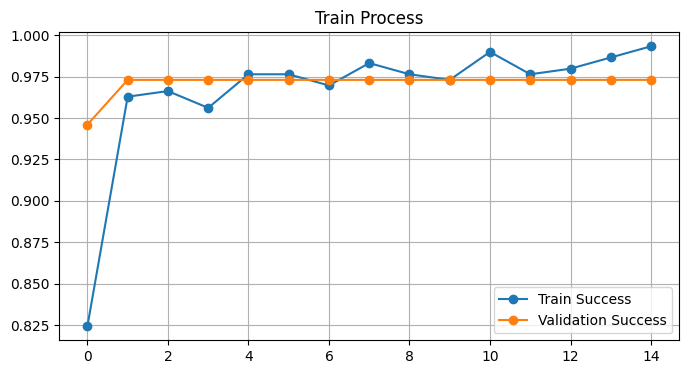

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 4))
plt.plot(acc, label='Train Success', marker='o')
plt.plot(val_acc, label='Validation Success', marker='o')
plt.legend(loc='lower right')
plt.title('Train Process')
plt.grid(True)
plt.show()

## Test

In [6]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet import preprocess_input
import matplotlib.pyplot as plt

Yapay zeka düşünüyor...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


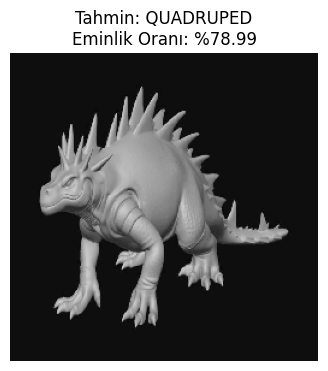

Sınıf Etiketleri ve İndeksleri: ['humanoid', 'quadruped']
Detaylı Olasılıklar: humanoid: %21.01 | quadruped: %78.99


In [30]:
TEST_IMAGE_PATH = r"C:\Users\fatih\Desktop\cover.jpg"

img = image.load_img(TEST_IMAGE_PATH, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # (1, 256, 256, 3) formatına çevir

# === CRITICAL FIX: Önişleme kodunu test resmine uygula ===
img_array = preprocess_input(img_array)
# ========================================================

# Tahmin yap!
print("Yapay zeka düşünüyor...")
predictions = model.predict(img_array)

# Çıkan sonucu yorumla
predicted_class_index = np.argmax(predictions)
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

# Resmi ve tahmini ekrana yazdır
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Tahmin: {predicted_class_name.upper()}\nEminlik Oranı: %{confidence:.2f}")
plt.show()

# Keras'ın sınıf etiketleme sırasını kontrol etmek için
print(f"Sınıf Etiketleri ve İndeksleri: {class_names}")
print(f"Detaylı Olasılıklar: {class_names[0]}: %{predictions[0][0]*100:.2f} | {class_names[1]}: %{predictions[0][1]*100:.2f}")